In [ ]:
#=====================================================================
# CELL 1: INSTALASI & IMPORT LIBRARY
# =====================================================================
!pip install google-play-scraper pysastrawi wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import os
from datetime import datetime

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from wordcloud import WordCloud

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Scraping
from google_play_scraper import Sort, reviews, app

# Download data NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Buat folder untuk menyimpan hasil
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)
os.makedirs('images', exist_ok=True)

print("✅ Semua library berhasil diimpor dan folder dibuat!")
print(f"📅 Waktu: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 938.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 1.7 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


✅ Semua library berhasil diimpor dan folder dibuat!
📅 Waktu: 2026-07-31 16:38:18


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# =====================================================================
# CELL 2: PENGUMPULAN DATA (WEB SCRAPING)
# =====================================================================
PACKAGE_NAME = 'superapps.polri.presisi.presisi' # ✅ Package name yang BENAR
COUNT = 3000

print(f"🔍 Mengambil {COUNT} ulasan dari aplikasi {PACKAGE_NAME}...")

try:
    app_info = app(PACKAGE_NAME, lang='id', country='id')
    print(f"📱 Nama Aplikasi: {app_info['title']}")

    result, _ = reviews(
        PACKAGE_NAME, lang='id', country='id',
        sort=Sort.NEWEST, count=COUNT, filter_score_with=None
    )

    df = pd.DataFrame(result)
    df = df[['userName', 'score', 'content', 'at', 'thumbsUpCount']]
    df.columns = ['user', 'rating', 'review', 'date', 'likes']

    # Simpan data mentah
    df.to_csv('data/data_mentah_superapp.csv', index=False, encoding='utf-8')
    print(f"✅ Berhasil mengambil {len(df)} ulasan dan disimpan ke CSV!")

except Exception as e:
    print(f"❌ Error saat scraping: {e}. Coba jalankan ulang cell ini.")

🔍 Mengambil 3000 ulasan dari aplikasi superapps.polri.presisi.presisi...
📱 Nama Aplikasi: Super App Polri
✅ Berhasil mengambil 3000 ulasan dan disimpan ke CSV!


📊 Distribusi Kelas Sentimen:
sentimen
positif    2297
negatif     581
netral      122
Name: count, dtype: int64


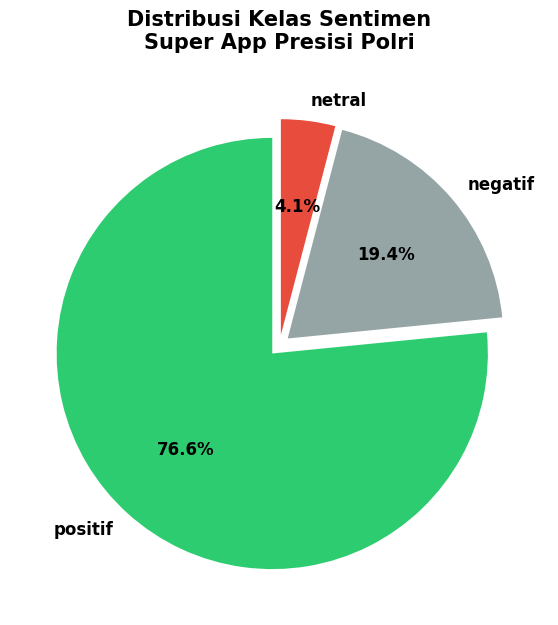

In [ ]:
# =====================================================================
# CELL 3: PELABELAN SENTIMEN (3 KELAS)
# =====================================================================
def label_sentimen(rating):
    if rating in [4, 5]: return 'positif'
    elif rating == 3: return 'netral'
    else: return 'negatif'

df['sentimen'] = df['rating'].apply(label_sentimen)

print("📊 Distribusi Kelas Sentimen:")
print(df['sentimen'].value_counts())

# Visualisasi Pie Chart
plt.figure(figsize=(7, 7))
colors = ['#2ecc71', '#95a5a6', '#e74c3c']
wedges, texts, autotexts = plt.pie(
    df['sentimen'].value_counts().values,
    labels=df['sentimen'].value_counts().index,
    autopct='%1.1f%%', colors=colors, startangle=90,
    explode=(0.05, 0.05, 0.05), textprops={'fontsize': 12, 'fontweight': 'bold'}
)
plt.title('Distribusi Kelas Sentimen\nSuper App Presisi Polri', fontsize=15, fontweight='bold', pad=20)
plt.savefig('images/distribusi_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# =====================================================================
# CELL 4: TEXT PREPROCESSING (6 TAHAP + PENGAMANAN NEGASI)
# =====================================================================
KAMUS_NORMALISASI = {
    'gak': 'tidak', 'ga': 'tidak', 'nggak': 'tidak', 'enggak': 'tidak',
    'udah': 'sudah', 'yg': 'yang', 'dgn': 'dengan', 'utk': 'untuk',
    'dr': 'dari', 'krn': 'karena', 'bgt': 'sangat', 'banget': 'sangat',
    'lemot': 'lambat', 'lelet': 'lambat', 'mantap': 'bagus', 'mantul': 'bagus'
}

KATA_NEGASI = {'tidak', 'tak', 'bukan', 'belum', 'tanpa', 'jangan', 'tiada', 'kurang'}
stopwords_id = set(stopwords.words('indonesian')) - KATA_NEGASI
stemmer = StemmerFactory().create_stemmer()

def preprocessing(teks):
    if not isinstance(teks, str): return ""
    # 1. Case Folding & 2. Cleaning
    teks = teks.lower()
    teks = re.sub(r'http\S+|www\S+|@\w+|#\w+|\d+|[^\w\s]', ' ', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()

    # 3. Normalisasi
    kata = [KAMUS_NORMALISASI.get(k, k) for k in teks.split()]

    # 4. Tokenisasi
    tokens = word_tokenize(' '.join(kata))

    # 5. Stopword Removal (dengan pengamanan negasi)
    tokens = [t for t in tokens if t not in stopwords_id]

    # 6. Stemming (dengan pengamanan negasi)
    tokens_stemmed = []
    for t in tokens:
        if t in KATA_NEGASI:
            tokens_stemmed.append(t) # Pertahankan kata negasi
        else:
            tokens_stemmed.append(stemmer.stem(t))

    return ' '.join(tokens_stemmed)

print("⏳ Sedang melakukan preprocessing (mohon tunggu 1-2 menit)...")
df['review_clean'] = df['review'].astype(str).apply(preprocessing)
df = df[df['review_clean'].str.strip() != ''].reset_index(drop=True)
print(f"✅ Preprocessing selesai! Sisa data valid: {len(df)} ulasan")

⏳ Sedang melakukan preprocessing (mohon tunggu 1-2 menit)...
✅ Preprocessing selesai! Sisa data valid: 2775 ulasan


📊 Sedang membuat Word Cloud... Mohon tunggu sebentar.


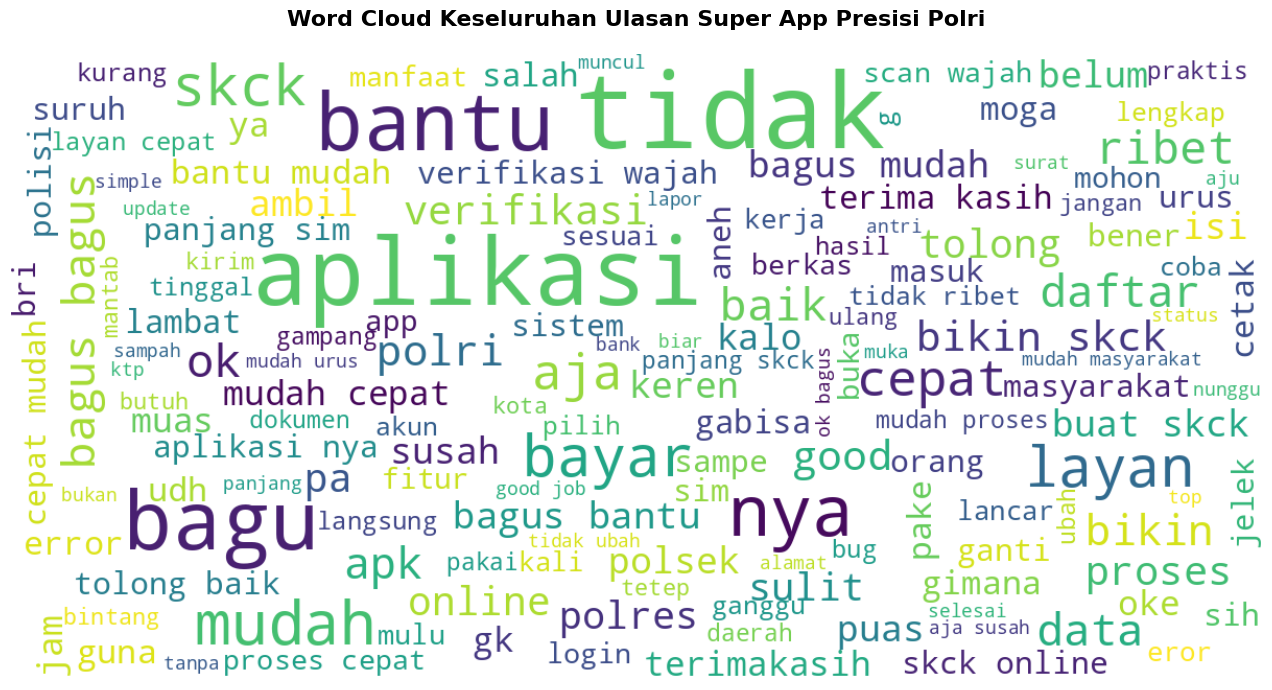

✅ Word Cloud Keseluruhan berhasil disimpan di folder 'images/'

📊 Sedang membuat Word Cloud per kelas sentimen...


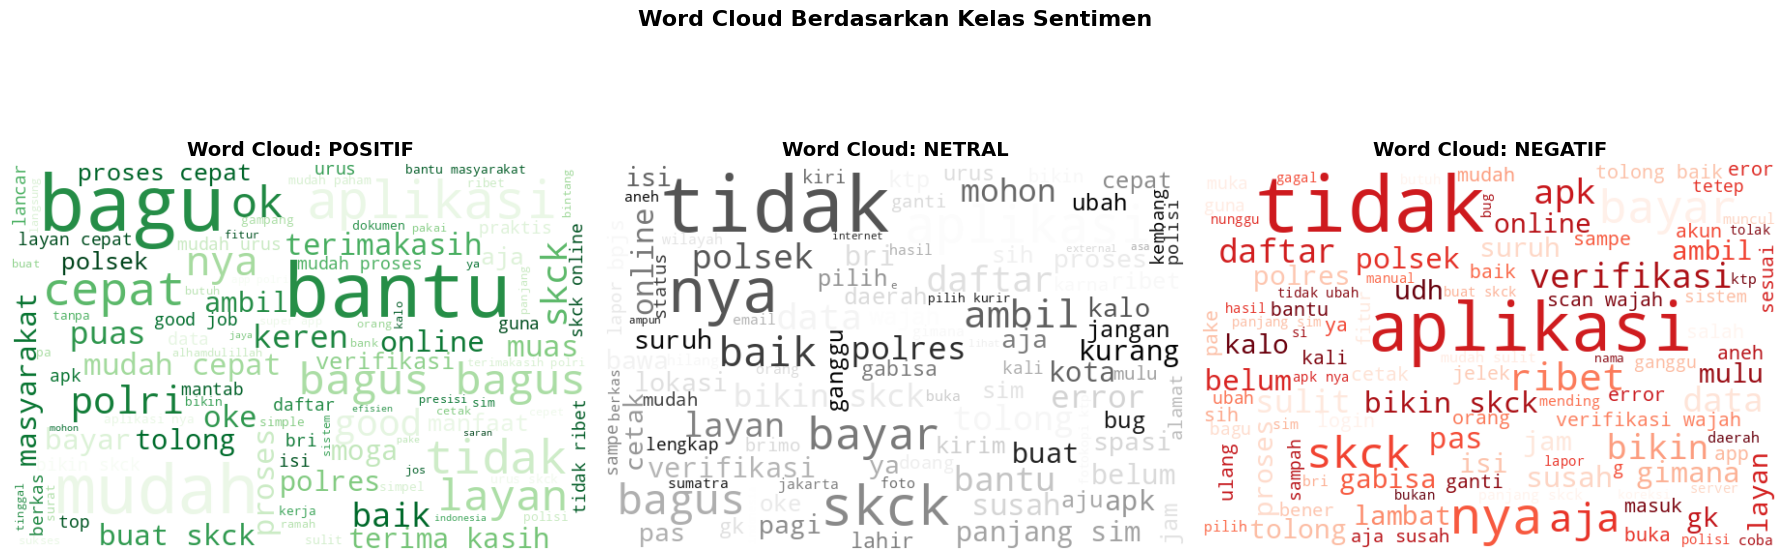

✅ Word Cloud per Kelas berhasil disimpan di folder 'images/'


In [ ]:
# =====================================================================
# CELL: VISUALISASI WORD CLOUD (Untuk Bab 4)
# =====================================================================
from wordcloud import WordCloud
import matplotlib.pyplot as plt

print("📊 Sedang membuat Word Cloud... Mohon tunggu sebentar.")

# Pastikan folder 'images' sudah ada (seharusnya sudah dibuat di Cell 1)
import os
os.makedirs('images', exist_ok=True)

# 1. WORD CLOUD KESELURUHAN
all_text = ' '.join(df['review_clean'].dropna())

wc_all = WordCloud(
    width=1200,
    height=600,
    background_color='white', # Penting agar background putih di Word
    colormap='viridis',
    max_words=150,
    max_font_size=100,
    random_state=42
).generate(all_text)

plt.figure(figsize=(14, 7))
plt.imshow(wc_all, interpolation='bilinear')
plt.title('Word Cloud Keseluruhan Ulasan Super App Presisi Polri',
          fontsize=16, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig('images/wordcloud_keseluruhan.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Word Cloud Keseluruhan berhasil disimpan di folder 'images/'")

# 2. WORD CLOUD PER KELAS SENTIMEN
print("\n📊 Sedang membuat Word Cloud per kelas sentimen...")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
kelas_list = ['positif', 'netral', 'negatif']
warna_list = ['Greens', 'Greys', 'Reds'] # Hijau, Abu-abu, Merah
judul_list = ['POSITIF', 'NETRAL', 'NEGATIF']

for ax, kelas_name, cmap, judul in zip(axes, kelas_list, warna_list, judul_list):
    # Gabungkan semua teks bersih untuk kelas tertentu
    teks_kelas = ' '.join(df[df['sentimen'] == kelas_name]['review_clean'].dropna())

    if teks_kelas.strip(): # Cek agar tidak error jika kelas kosong
        wc = WordCloud(
            width=600,
            height=400,
            background_color='white',
            colormap=cmap,
            max_words=100,
            max_font_size=80,
            random_state=42
        ).generate(teks_kelas)
        ax.imshow(wc, interpolation='bilinear')

    ax.set_title(f'Word Cloud: {judul}', fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Cloud Berdasarkan Kelas Sentimen', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('images/wordcloud_per_kelas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Word Cloud per Kelas berhasil disimpan di folder 'images/'")

In [ ]:
# =====================================================================
# CELL 5: EKSTRAKSI FITUR TF-IDF & SPLIT DATA
# =====================================================================
X = df['review_clean']
y = df['sentimen']

# Split 80:20 dengan stratify agar proporsi kelas seimbang
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF Vectorizer sesuai spesifikasi Bab 3
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test) # Hanya transform, jangan fit!

print(f"✅ TF-IDF selesai!")
print(f"📊 Jumlah fitur (kosakata): {X_train_tfidf.shape[1]}")
print(f"📊 Data latih: {len(X_train)}, Data uji: {len(X_test)}")

✅ TF-IDF selesai!
📊 Jumlah fitur (kosakata): 1682
📊 Data latih: 2220, Data uji: 555


In [ ]:
# =====================================================================
# CELL 6: TRAINING SVM + GRID SEARCH
# =====================================================================
print("⏳ Sedang melakukan Grid Search (ini paling lama, mohon tunggu 3-5 menit)...")

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['linear', 'rbf']
}

svm = SVC(random_state=42, class_weight='balanced', probability=True)
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_tfidf, y_train)

model_best = grid_search.best_estimator_
print("\n" + "="*50)
print("✅ HASIL OPTIMASI")
print("="*50)
print(f"🏆 Parameter Terbaik: {grid_search.best_params_}")
print(f"🏆 Akurasi CV Terbaik: {grid_search.best_score_:.4f}")

⏳ Sedang melakukan Grid Search (ini paling lama, mohon tunggu 3-5 menit)...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

✅ HASIL OPTIMASI
🏆 Parameter Terbaik: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
🏆 Akurasi CV Terbaik: 0.8586


In [ ]:
# =====================================================================
# HYPERPARAMETER TUNING DENGAN GRID SEARCH (SVM)
# =====================================================================
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

print("="*70)
print("🚀 MEMULAI PROSES HYPERPARAMETER TUNING (GRID SEARCH)")
print("="*70)

# 1. Definisikan Ruang Pencarian Parameter (Parameter Grid)
# Sesuai Bab 3: Menguji kombinasi parameter C, gamma, dan kernel
param_grid = {
    'C': [0.1, 1, 10, 100],               # Parameter regularisasi (mengontrol trade-off margin vs error)
    'gamma': ['scale', 'auto', 0.01, 0.1], # Parameter kernel RBF (mengatur radius pengaruh titik data)
    'kernel': ['linear', 'rbf']            # Jenis kernel (Linear untuk data linear, RBF untuk non-linear)
}

print(f"🔍 Jumlah kombinasi parameter yang akan diuji: {4 * 4 * 2} = 32 kombinasi")
print(f"🔍 Validasi: 5-fold cross-validation")
print(f"🔍 Total proses fitting model: 32 kombinasi × 5 fold = 160 kali")
print("⏳ Mohon tunggu, proses ini memakan waktu beberapa menit (jangan di-stop)...\n")

# 2. Inisialisasi Model SVM Dasar
# PENTING: probability=True ditambahkan agar model bisa menghasilkan confidence score (predict_proba) di Gradio nanti
svm_base = SVC(random_state=42, class_weight='balanced', probability=True)

# 3. Konfigurasi GridSearchCV
grid_search = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid,
    cv=5,                  # 5-fold cross-validation sesuai Bab 3
    scoring='accuracy',    # Metrik yang dioptimasi untuk mencari kombinasi terbaik
    n_jobs=-1,             # Menggunakan semua core CPU tersedia untuk mempercepat proses
    verbose=1              # Menampilkan progress bar saat proses berjalan
)

# 4. Jalankan Proses Pencarian pada Data Latih
# (Pastikan variabel X_train_tfidf dan y_train sudah tersedia dari cell sebelumnya)
grid_search.fit(X_train_tfidf, y_train)

# 5. Ambil Model Terbaik dari Hasil Grid Search
model_terbaik = grid_search.best_estimator_

# 6. Tampilkan Hasil Optimasi
print("\n" + "="*70)
print("✅ HASIL HYPERPARAMETER TUNING SELESAI")
print("="*70)
print(f"🏆 Kombinasi Parameter Terbaik : {grid_search.best_params_}")
print(f"🏆 Akurasi Cross-Validation Terbaik : {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")
print("="*70)

# Opsional: Lihat performa semua kombinasi (jika ingin ditampilkan di Bab 4)
# results_df = pd.DataFrame(grid_search.cv_results_)
# print(results_df[['param_C', 'param_gamma', 'param_kernel', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False).head())

🚀 MEMULAI PROSES HYPERPARAMETER TUNING (GRID SEARCH)
🔍 Jumlah kombinasi parameter yang akan diuji: 32 = 32 kombinasi
🔍 Validasi: 5-fold cross-validation
🔍 Total proses fitting model: 32 kombinasi × 5 fold = 160 kali
⏳ Mohon tunggu, proses ini memakan waktu beberapa menit (jangan di-stop)...

Fitting 5 folds for each of 32 candidates, totalling 160 fits

✅ HASIL HYPERPARAMETER TUNING SELESAI
🏆 Kombinasi Parameter Terbaik : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
🏆 Akurasi Cross-Validation Terbaik : 0.8586 (85.86%)


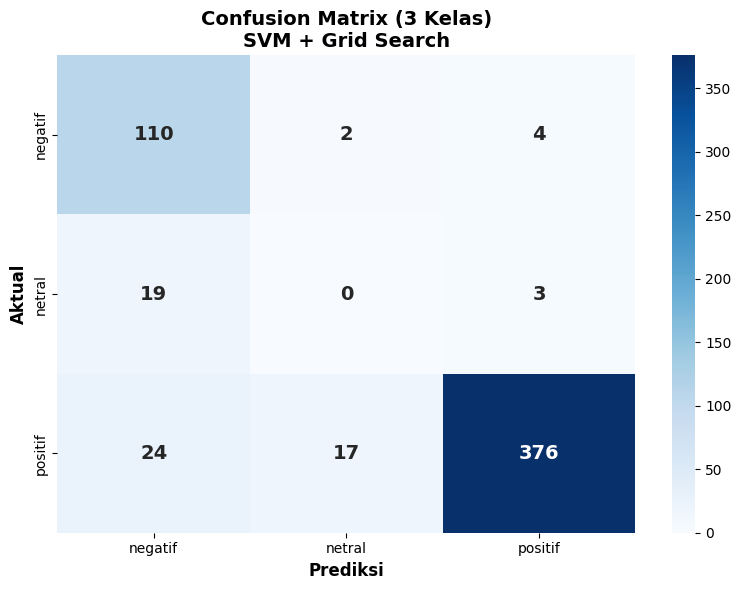


📊 HASIL EVALUASI PADA DATA UJI (Weighted Average)
   Akurasi  : 87.57%
   Presisi  : 88.79%
   Recall   : 87.57%
   F1-Score : 87.72%

📋 CLASSIFICATION REPORT DETAIL:
              precision    recall  f1-score   support

     negatif       0.72      0.95      0.82       116
      netral       0.00      0.00      0.00        22
     positif       0.98      0.90      0.94       417

    accuracy                           0.88       555
   macro avg       0.57      0.62      0.59       555
weighted avg       0.89      0.88      0.88       555



In [ ]:
# =====================================================================
# CELL: EVALUASI MODEL KLASIFIKASI
# =====================================================================
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Lakukan prediksi pada data uji menggunakan model terbaik
y_pred = model_terbaik.predict(X_test_tfidf)
classes = ['negatif', 'netral', 'positif'] # Urutan alfabetis default sklearn

# 2. Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            annot_kws={'size': 14, 'fontweight': 'bold'})
plt.title('Confusion Matrix (3 Kelas)\nSVM + Grid Search', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi', fontsize=12, fontweight='bold')
plt.ylabel('Aktual', fontsize=12, fontweight='bold')
plt.tight_layout()

# Simpan gambar untuk Bab 4
plt.savefig('images/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Hitung Metrik Evaluasi (Weighted Average)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\n" + "="*60)
print("📊 HASIL EVALUASI PADA DATA UJI (Weighted Average)")
print("="*60)
print(f"   Akurasi  : {accuracy*100:.2f}%")
print(f"   Presisi  : {precision*100:.2f}%")
print(f"   Recall   : {recall*100:.2f}%")
print(f"   F1-Score : {f1*100:.2f}%")
print("="*60)

# Opsional: Lihat laporan detail per kelas
print("\n📋 CLASSIFICATION REPORT DETAIL:")
print(classification_report(y_test, y_pred, target_names=classes))

In [ ]:
# =====================================================================
# CELL: SIMPAN MODEL FINAL
# =====================================================================
import joblib

# Simpan model SVM terbaik
joblib.dump(model_terbaik, 'models/model_svm_best.pkl')

# Simpan vectorizer TF-IDF
joblib.dump(tfidf, 'models/tfidf_vectorizer.pkl')

# Simpan metadata (nilai metrik dan parameter) untuk referensi
joblib.dump({
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'best_params': grid_search.best_params_,
    'classes': list(model_terbaik.classes_)
}, 'models/model_metadata.pkl')

print("="*60)
print("✅ MODEL BERHASIL DISIMPAN DI FOLDER 'models/'")
print("="*60)
print("💡 LANGKAH SELANJUTNYA:")
print("1. Buka ikon Folder (📁) di bilah kiri Colab.")
print("2. Buka folder 'models/' dan 'images/'.")
print("3. Klik kanan pada 'model_svm_best.pkl', 'tfidf_vectorizer.pkl', dan 'confusion_matrix.png' lalu pilih DOWNLOAD.")
print("4. File ini akan Anda gunakan di Notebook 2 (Gradio) dan untuk Bab 4 skripsi.")
print("="*60)

✅ MODEL BERHASIL DISIMPAN DI FOLDER 'models/'
💡 LANGKAH SELANJUTNYA:
1. Buka ikon Folder (📁) di bilah kiri Colab.
2. Buka folder 'models/' dan 'images/'.
3. Klik kanan pada 'model_svm_best.pkl', 'tfidf_vectorizer.pkl', dan 'confusion_matrix.png' lalu pilih DOWNLOAD.
4. File ini akan Anda gunakan di Notebook 2 (Gradio) dan untuk Bab 4 skripsi.
